## This notebook is for fitting the spiral arms of HD34700 by eye

Notes: 
- the code assumes that the azimuth angles on the x axis are 360 degrees, so that each pixel is one degree.
- Polar shift often inserted directly as -90°.
- Irdis pixel scale 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
#from mpl_toolkits.axes_grid1.inset_locator import inset_axes
#from astropy.stats import sigma_clip
import vip_hci as vip
import pandas as pd
from scipy import ndimage
# %matplotlib inline
from contextlib import redirect_stdout
import sys
sys.path.insert(1, '/home/gabriele/ExoDisks/gab_products/Scrypts')    # caution: path[0] is reserved for script path (or '' in REPL)
import deprojection as deproj
import ring_analysis_funcs as raf

plt.rcParams.update({ 'font.size':14, 'legend.fontsize':12})
zimp_scale = 3.516
ird_scale = 12.255
polshift = -90

useful functions ?

In [3]:
def logvalues_shift( data):
    '''Shift all pixel values to have 1 as minimum and return the logarithm.'''
    shifted = data.copy() + 1 - np.nanmin( data)
    logged = np.log( shifted)
    return logged


# def rectifier( data, sp_type='log', a=50, b=0.02, clockwise=False, figure=False):
#     '''
#     Transform a polar-coordinate image, mapping spiral features to vertical lines.
#     type: log, arch
#     clockwise: spiral winding, clockwise if it increases as theta increases
#     '''
#     if clockwise == True: sign = +1
#     else: sign = -1
#     xx, yy = np.meshgrid( np.arange(data.shape[1]), np.arange(data.shape[0]))    # y axis is r and x is theta
#     if sp_type =='log':
#         shift =  1./b * np.log( yy / a , where= yy>0 )      # horizontal shifts matrix
#     else:
#         shift = ( yy - a ) / b
#     # map the transformation to rectify spirals
#     rectified = ndimage.map_coordinates( data, [ yy , xx + sign* shift], order=3, mode='grid-wrap', cval=0 )    # grid-wrap takes care of values beyond edges
#     if figure:
#         cnorm = mpl.colors.SymLogNorm( vmin=rectified.min(), vmax=rectified.max(), linthresh=3e-05, linscale=0.8, base=np.e)
#         plt.imshow( rectified, origin='lower', cmap='inferno', norm=cnorm )
#         plt.show()
#     return rectified


# def test_rectifier( sp_type='log', figures=True):
#     '''quick rectifier check'''
#     mockdata = np.full( (250,360), fill_value=2)
#     xx, yy = np.meshgrid( np.arange(mockdata.shape[1]), np.arange(mockdata.shape[0]))    # y axis is r and x is theta
#     a = 40
#     b = 0.02    # create few spirals
#     theta_0 = [89,90,91,  135, 179,180, 181, 200, 270]
#     for t0 in theta_0:
#         if sp_type == 'log':
#             sp = yy == np.round( a * np.exp(b*( xx - t0)) )
#         else:   # archimedean
#             b = 1
#             sp = yy == np.round( a + b *( xx - t0 ) )
#         mockdata[ sp ] = 10
#     if figures:
#         plt.imshow( mockdata, origin='lower')
#         plt.show()
#     rekt = rectifier( data=mockdata, sp_type= sp_type, a=a, b=b, clockwise=True, figure=figures)
#     return mockdata, rekt


# def squash( data, mode='sum', r_lims=[None, None]):
#     '''Compute the vertical sum or median of the data -between r_lims- to see the peak values and their locations.'''
#     t_data = data[ slice(*r_lims) ]
#     if mode == 'sum':
#         return t_data.sum( axis=0 )
#     else:
#         return np.nanmedian( t_data, axis=0)


Fits HDU-0 data successfully loaded. Data shape: (1024, 1024)
Filename: /home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      70   (1024, 1024)   float32   
New shape: (1023, 1023)


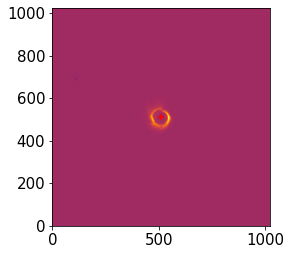

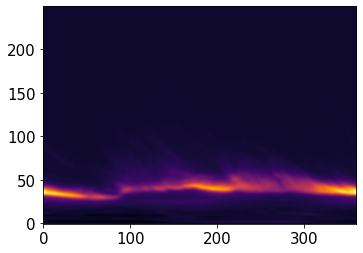

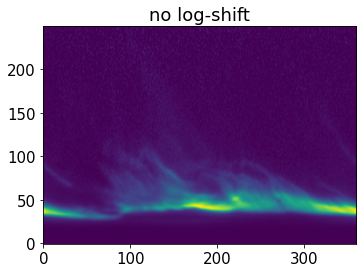

In [23]:
# load and transform to polar domain the images
# fname = '/home/gabriele/ExoDisks/HD34700_27-10-2019_r/ird_specal_dc-IRD_SPECAL_MEDIAN_RESIDUAL_CUBE-cube_reduced_image_median_img.fits'      # ADI
fname = '/home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits'      # the Qphi frame from H band 2019 IRDIS         # Qphi
img = vip.fits.fits.open_fits( fname)
# centre = [511.5, 511.5]
centre = list( ( np.array(img.shape) -1 )/2 )
pol_img = deproj.main( fname, PA_majaxis=87, inclination=39.7, centre=centre, polar_shift=-90, flaring_ang=0, sigma_smooth=0, badpix_thresh=None, r2correction=False, figs=True ) [1]
# plt.imshow( pol_img[:], origin='lower')

pol_img = np.nan_to_num( pol_img, nan=0)                # NaNs give problems with rectifier()
pol_img[ pol_img < 0] = 0           # remove the bkg noise (legal?)
pol_img_r2 = deproj.r2_correction( pol_img, polar=True)
lpol = logvalues_shift( pol_img_r2 )
lpol = pol_img_r2

plt.imshow( pol_img_r2, origin='lower')
plt.title( 'no log-shift')
plt.show()
# plt.imshow( lpol, origin='lower')
# plt.title( 'log-shifted')
# plt.show()

The two kinds of spiral have the following form:

Archimedean:  $ r(\phi) = a + b \phi $    $ \qquad \qquad $     pitch angle f(r): $\alpha = \frac{r}{\sqrt{b^2 + r^2}} $ 

Logarithmic:  $ r(\phi) = r_0 + a e^{b \phi} $    $ \qquad \qquad $     pitch angle: $\alpha = \arctan( b ) $

with $\phi$ the azimuthal angle on the disk plane

In [2]:
def plot_spiral( data, sp_type, a, b, r0=0, phi0=0, polshift=-90, data_bound=True):
    
    # sign = +1 if (clockwise == True) else -1    # direction of spiral increase
    x = np.arange( data.shape[1] )          # the x coordinates on the data
    phi = np.deg2rad( x - phi0 + polshift )              # the az angles corresponding to each x, centred on phi0, accounting for polshift 
    if sp_type == 'log':
        r = a * np.exp( b * phi) + r0
    else: # archimedean
        r = a + b * phi
    if data_bound:
        bound = ( r > 1 ) & ( r < data.shape[0] - 1 )
        r = r[bound]
        x = x[bound]
    return x, r


def au_to_pix( au, scale, parallax=2.85):
    return au * parallax / scale

def pix_to_au( pix, scale, parallax=2.85):
    return pix * scale / parallax

def au_deg_ticks( ax_obj, shift, pixscale):
    '''Format the ticks to put au on the Y and degrees on the X, for horizontal polar images.'''
    def au_format( value, pos):
        """The two arguments are the value and tick position"""
        x_au = pix_to_au( value, scale=pixscale)
        return f'{x_au :3.0f}'

    def deg_format( value, pos):
        x_deg = value + shift
        return f'{x_deg :.0f}'

    ax_obj.yaxis.set_major_locator( mpl.ticker.MultipleLocator( au_to_pix( 100, pixscale) ))
    ax_obj.yaxis.set_minor_locator( mpl.ticker.MultipleLocator( au_to_pix( 50, pixscale) ))
    ax_obj.yaxis.set_major_formatter( au_format )
    ax_obj.xaxis.set_major_locator( mpl.ticker.MultipleLocator( 90 ))
    ax_obj.xaxis.set_minor_locator( mpl.ticker.MultipleLocator( 20 ))
    ax_obj.xaxis.set_major_formatter( deg_format )   
    return



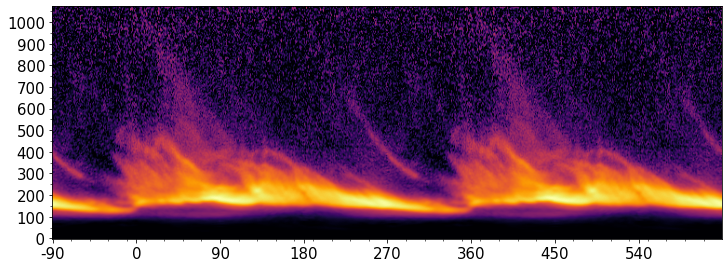

In [29]:
ext = np.concatenate( [lpol, lpol], axis=1)         # create an extended figure along Phi
# x, y = plot_spiral( ext, 'log', a=61, b= -1.3, r0=30 , phi0=370, polshift=-90)

fig, ax = plt.subplots( figsize=(12,8))
cnorm = mpl.colors.SymLogNorm( vmin=ext.min(), vmax=ext.max(), linthresh=1.8, linscale=0.8, base=np.e)
ax.imshow( ext, origin='lower', cmap='inferno', norm=cnorm)
# ax.scatter( x, y, 4, c='r' , alpha=0.3)
au_deg_ticks( ax, -90, ird_scale)        # this only changes the label format, not the actual xy values of rows n cols
plt.show()

Let's do a neat thing: hand pick the points with a click of the mouse and have the coordinates written on a file

Note: the x and y coordinates reported by clicking are not affected by the formatting of the axes, they are pixel values!

In [116]:
def onclick(event):
    '''Function to assign an action for every mouse click on the figure.'''
    x_pix = event.xdata
    y_pix = event.ydata
    print(x_pix, '\t', y_pix)    # to save on file must redirect stdout

This part is to execute in a terminal !
Change filename to do different spirals

In [ ]:
def handpick_spiral( fname, dataset, pixscale=ird_scale):
    '''Open interactive extended plot and send to fname the coordinates of your clicks'''
    with open( fname, 'a') as f:  #   append mode to avoid overwriting
        with redirect_stdout(f):        # to print on file
            fig, ax = plt.subplots( figsize=(16,9))         # this figure better for Qphi
            au_deg_ticks( ax, -90, pixscale=pixscale)        # this only changes the label format, not the actual xy values of rows n cols
            cnorm = mpl.colors.SymLogNorm( vmin=dataset.min(), vmax=dataset.max(), linthresh=1, linscale=0.1, base=np.e)
            ax.imshow( dataset, origin='lower', cmap='inferno', norm=cnorm )
            cid = fig.canvas.mpl_connect('button_press_event', onclick )
            # fig.canvas.mpl_disconnect(cid)      # useful?
            plt.show()

handpick_spiral( 'spi_S1_q.dat', Qphi_ext)

Now load a coordinate file and fit a spiral equation: example with S1

In [3]:
from scipy.optimize import curve_fit

def log_spiral( x, a, b, phi0, r0=0):
    '''x is the azimuthal position in pixel. All angle inputs in DEG'''
    phi = np.deg2rad( x - phi0 + -90 )     # from coord to actual azim angle on disk plane (-90 is the polshift)
    r = a * np.exp( b * phi) + r0
    return r

def arch_spiral( x, a, b, phi0):
    phi = np.deg2rad( x - phi0 + -90 )     # from coord to actual azim angle on disk plane (-90 is the polshift)
    r = a + b * phi
    return r


In [17]:
folder = './Datapoints/'
fname = folder + 'spi_S1_q.dat'
data = np.loadtxt( fname )
data = data[1:84]       # 84 to avoid the points on the outer ring, which do not convince me anymore

fit: a= 23.603 [pix], b= -0.699 [1/rad], phi0= 380.896 [deg], r0 =1.000 [pix]
Fit 1 sigma errors: [1.30017987e+07 7.49904026e-02 4.51778161e+07 9.64856177e+00]
reduced chi-square of fit:  0.06133836295412559
abs pitch angle: [deg] 34.93871803137348


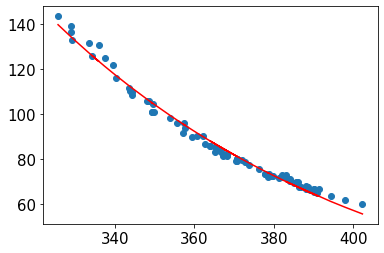

In [18]:
# a prescindere da che phi0 scelgo per centrare la spirale, il valore di b (e quindi del pitch ang) mi sembra resti invariato
param_bounds = ( [0, -np.inf, -360, 0], [250, np.inf, 720, 1] )        # limits on spiral parameters a, b, phi0, r0

IN_popt, IN_pcov = curve_fit( log_spiral, xdata= data[:,0], ydata= data[:,1], p0=([10, -0.1, 360, 0]), bounds=param_bounds, absolute_sigma=False )
fit_std = np.sqrt(np.diag( IN_pcov ))       # from scipy doc
print( 'fit: a= %.3f [pix], b= %.3f [1/rad], phi0= %.3f [deg], r0 =%.3f [pix]' % tuple(IN_popt) )
print( 'Fit 1 sigma errors:', fit_std )     # errors on a and r0 are enormous
y_pred = log_spiral( data[:,0], *IN_popt)
res = y_pred - data[:,1]
chisq = sum( res** 2 / y_pred) / (len( data) - 4)   # res.T @ np.linalg.inv(fit_std) @ res  #
print( 'reduced chi-square of fit: ', chisq )
print( 'abs pitch angle: [deg]', abs( np.rad2deg( np.arctan( IN_popt[1]))) )

plt.scatter(data[:,0], data[:,1])
plt.plot( data[:,0], y_pred , c='r')
plt.show()

### Automatic fit of all spirals

In [4]:
import glob

def arm_bounds( arm_ID, folder='./Datapoints2/' ):
    '''
    Find the endpoints of the spiral arm based on the sampled coordinates points of given arm.
    '''
    filelist = sorted( glob.glob( f'{folder}*{arm_ID}*.dat', recursive=True) )
    extrema = np.array([])
    for file in filelist: 
        data = np.loadtxt( file )
        points = data[1:]         # remove first line since it was a zoom click
        for i in [0,1]:     # cycle on x and y
            extrema = np.append(  extrema, [points[:,i].min(), points[:,i].max() ] )    # xmin, xmax, ymin, ymax for each file : one line
    extr = extrema.reshape(-1,4)
    xmin, ymin = extr[:,[0,2]].min( axis=0)
    xmax, ymax = extr[:,[1,3]].max( axis=0)
    return (xmin, xmax), (ymin, ymax)


def pitch_angle( sp_type, b , r_ev=40, absval=True):
    '''Returns pitch angle for given spiral tipe. r_ev is the evalutation radius to compute the archimedean pitch angle'''
    if sp_type == 'log':
        p =  np.rad2deg( np.arctan( b ) )
    else:   # arch
        p = np.rad2deg( np.arccos( r_ev/np.sqrt( b**2 + r_ev**2) ) )    # r and b must have same units
    if absval:
        p = abs(p)
    return p


def pitch_error( sp_type, b_best, stds, r_ev):
    '''Provide an error based on the one sigma distance b values.'''
    b_lo = b_best - stds[1] #* ([-1, +1])
    b_hi = b_best + stds[1]
    p_lo = pitch_angle( sp_type=sp_type, b=b_lo, r_ev=r_ev )
    p_hi = pitch_angle( sp_type=sp_type, b=b_hi, r_ev=r_ev )
    err = ( p_hi - p_lo) / 2
    return abs(err)


def fit_spiral( data, sp_type, prints=True, figure=True, arm_name='', folder='./Datapoints2/'):
    '''Fit the datapoints to the chosen spiral type equation. Prints the resulting fit parameters, the pitch angle and the chisquare.'''
    if sp_type == 'log':
        spiral_func = log_spiral
        param_bounds = ( [0, -np.inf, -360, 0], [250, np.inf, 720, 0.1] )        # limits on spiral parameters a, b, phi0, (r0 constrained)
        init_guess = ([10, -0.8, 180, 0])
    else:
        spiral_func = arch_spiral
        param_bounds = ( [-250, -np.inf, -360], [250, np.inf, 720] )           # limits on spiral parameters a, b, phi0
        init_guess = ([10, -3.6, 180])

    IN_popt, IN_pcov = curve_fit( spiral_func, xdata= data[:,0], ydata= data[:,1], p0=init_guess, bounds=param_bounds, absolute_sigma=False )
    fit_stds = np.sqrt(np.diag( IN_pcov ))          # from scipy doc
    y_pred = spiral_func( data[:,0], *IN_popt)       # fit predictions
    res = y_pred - data[:,1]                        # residues
    chisq = sum( res**2 / y_pred) / ( len(data) - len(init_guess) )        # reduced chi-square
    arm_ID = arm_name.replace( 'spi_', '').replace( '_q', '').replace( '_a', '')      # clean names
    eval_rad = arm_bounds( arm_ID=arm_ID, folder=folder )[1][0]            # r_ev = ymin for each arm
    pitch_ang = pitch_angle( sp_type=sp_type, b= IN_popt[1], absval=True, r_ev= eval_rad )
    pitch_std = pitch_error( sp_type=sp_type, b_best=IN_popt[1], stds=fit_stds, r_ev= eval_rad)
    if prints:
        print( 'fit: a= %.3f [pix], b= %.3f [1/rad], phi0= %.2f [deg]' % tuple(IN_popt[0:3]) )
        if sp_type == 'log': print( f'r0 = {IN_popt[-1] :.2f} [pix]')
        print( 'Fit 1 sigma errors:', fit_stds )     # errors on a and r0 are enormous
        print( f'reduced chi-square of fit: \t {chisq :.3f}' )
        print( f'abs pitch angle: [deg] \t {pitch_ang :.2f}' )
    if figure:
        xsort = np.argsort( data[:,0] )     # to draw the lines monotonically
        fig, ax = plt.subplots( figsize=(7,5), constrained_layout=True)
        # au_deg_ticks( ax, -90, ird_scale)        # this only changes the label format, not the actual xy values of rows n cols
        # cnorm = mpl.colors.SymLogNorm( vmin=dataset.min(), vmax=dataset.max(), linthresh=3e-05, linscale=0.8, base=np.e)
        #ax.imshow( dataset, origin='lower', cmap='inferno', norm=cnorm )
        ax.scatter(data[:,0], data[:,1], c='tab:green', alpha=0.65)
        ax.plot( data[:,0][xsort], y_pred[xsort], c='tab:blue')
        ax.annotate( text=f'$\chi^2$ = {chisq :.2f}', xy=(0.6, 0.8), xycoords='axes fraction', color='k')
        ax.set( xlabel='$\phi$  (°)', ylabel='$r$  (pix)', title=f'{sp_type} fit: {arm_name}' )
        plt.show()
    return [ *IN_popt, pitch_ang, chisq, *fit_stds, pitch_std]

In [7]:
def perform_spiral_fit( folder='./Datapoints2/', figures=False):     # takes around 1s for each spiral arm
    '''
    Open all files with spiral datapoints (x,y coords), perform spiral fit and returns a dataframe with resulting parameters.
    '''
    filelist = sorted( glob.glob( f'{folder}/*.dat', recursive=True) )
    log_array = np.array([])
    arch_array = np.array([])

    for file in filelist:
        sp_name = file.replace( folder, '' ).replace( '.dat', '' )     # useful as IDs
        data = np.loadtxt( file )
        points = data[1:]         # remove first line since it was a zoom click
        log_params = fit_spiral( points, sp_type='log', prints=False, figure=figures, arm_name=sp_name, folder=folder)
        log_array = np.concatenate( ( log_array, [sp_name, 'log', *log_params]) )
        arch_params = fit_spiral( points, sp_type='arch', prints=False, figure=figures, arm_name=sp_name, folder=folder)
        arch_array = np.concatenate( (arch_array, [sp_name, 'arch', *arch_params]) )
    
    column_log = { 0:'filename', 1:'spiral_type', 2:'a', 3:'b', 4:'phi0', 5:'r0', 6:'pitch_ang', 7:'chi2', 8:'std_a', 9:'std_b', 10:'std_phi0', 11:'std_r0', 12:'std_pitch'}
    column_arch = { 0:'filename', 1:'spiral_type', 2:'a', 3:'b', 4:'phi0', 5:'pitch_ang', 6:'chi2', 7:'std_a', 8:'std_b', 9:'std_phi0', 10:'std_pitch'}
    log_df = pd.DataFrame( log_array.reshape( len(filelist), 13) )
    log_df.rename( columns= column_log, inplace=True )
    arch_df = pd.DataFrame( arch_array.reshape( len(filelist), 11 )  )
    arch_df.rename( columns= column_arch, inplace=True )

    for df in [log_df, arch_df]:     # pandas won't change dtype for many columns at once bah
        for i in range(2, df.shape[1]):
            df.iloc[:, i] = df.iloc[:, i].astype(float)

    merged_df = log_df.merge( arch_df, how='outer')
    return merged_df


In [123]:
m_df = perform_spiral_fit( folder='./Datapoints/')
m_df.sort_values( by=['filename'], inplace=True )

In [124]:
# to save it to file
# m_df.to_csv( 'Spiral_fit_results.txt', sep='\t')

Let's check the fit results visually

In [125]:
# perform_spiral_fit( figures=True)     # this one to see each arm one by one on top of the scattered points

In [126]:
# fig, ax = plt.subplots( figsize=(12,6))
# cnorm = mpl.colors.SymLogNorm( vmin=ext.min(), vmax=ext.max(), linthresh=3e-07, linscale=0.8, base=np.e)
# ax.imshow( ext, origin='lower', cmap='inferno', norm=cnorm, aspect='auto')
# au_deg_ticks( ax, -90, ird_scale)        # this only changes the label format, not the actual xy values of rows n cols

# for i in range( m_df.shape[0]):
#     if m_df.chi2[i] < 10:
#         col = 'r' if m_df.spiral_type[i]=='log' else 'blue'
#         x, y = plot_spiral( ext, m_df.spiral_type[i], m_df.a[i], m_df.b[i], m_df.r0[i], m_df.phi0[i], polshift=-90)
#         ax.plot( x, y, 4, c=col, ls='--' , alpha=0.8)
# plt.show()


In [5]:
def create_ext_img( fname, pixscale=ird_scale, figure=False, smoothing=0, logshift=False):
    img = vip.fits.fits.open_fits( fname)
    # centre = [511.5, 511.5]
    centre = list( ( np.array(img.shape) -1 )/2 )
    pol_img = deproj.main( fname, PA_majaxis=88.25, inclination=38.15, centre=centre, polar_shift=-90, flaring_ang=0, sigma_smooth=smoothing, badpix_thresh=None, r2correction=False, figs=False ) [1]
    pol_img = np.nan_to_num( pol_img, nan=0)                # NaNs give problems with rectifier()
    pol_img[ pol_img < 0] = 0           # remove the bkg noise (legal?)
    pol_img_r2 = deproj.r2_correction( pol_img, polar=True)
    if logshift:
        pol = logvalues_shift( pol_img_r2 )
    else: pol = pol_img_r2
    ext = np.concatenate( [pol, pol], axis=1)         # create an extended figure along Phi axis

    if figure:
        if pixscale == ird_scale:
            cnorm = mpl.colors.SymLogNorm( vmin=ext.min(), vmax=ext.max(), linthresh=1, linscale=0.2, base=10)
        else: cnorm = None
        fig, ax = plt.subplots( figsize=(14,5))
        ax.imshow( ext, origin='lower', aspect='auto', cmap='inferno', norm=cnorm)
        au_deg_ticks( ax, -90, pixscale=pixscale)        # this only changes the label format, not the actual xy values of rows n cols
        ax.set( title= 'extended polar image', xlabel= '$\phi $ (°)', ylabel= '$r$  (au)', frame_on =False)
        plt.show()
    return ext

# load both images
adi_fname = '/home/gabriele/ExoDisks/HD34700_27-10-2019_r/ird_specal_dc-IRD_SPECAL_MEDIAN_RESIDUAL_CUBE-cube_reduced_image_median_img.fits'      # ADI
Qphi_fname = '/home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits'      # the Qphi frame from H band 2019 IRDIS         # Qphi

adi_ext = create_ext_img( adi_fname)
Qphi_ext = create_ext_img( Qphi_fname)

Fits HDU-0 data successfully loaded. Data shape: (1448, 1448)
Filename: /home/gabriele/ExoDisks/HD34700_27-10-2019_r/ird_specal_dc-IRD_SPECAL_MEDIAN_RESIDUAL_CUBE-cube_reduced_image_median_img.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   (1448, 1448)   float32   


New shape: (1447, 1447)
Fits HDU-0 data successfully loaded. Data shape: (1024, 1024)
Filename: /home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      70   (1024, 1024)   float32   
New shape: (1023, 1023)


We need to prune more our results dataframe: for each spiral arm I select the results with the best fit, the best chi2 or the mean of the two (between ADI and Qphi)

In [128]:
chi_f = m_df[ m_df.chi2 < 10]       # filter by chi2  (S3 is excluded from this one, add it later)
chi_f

,filename,spiral_type,a,b,phi0,r0,pitch_ang,chi2,std_a,std_b,std_phi0,std_r0,std_pitch
0,spi_C1_q,log,157.566090,-0.614602,350.444645,8.810617e-01,31.574955,0.007203,5.913033e+07,0.158505,3.498456e+07,22.198117,6.595134
14,spi_C1_q,arch,212.434950,-52.900081,271.652039,NaN,37.403479,0.010017,4.522379e+07,0.884983,4.898163e+07,NaN,0.462517
1,spi_C2_q,log,18.457314,-0.841796,195.454392,5.939944e-12,40.090523,0.157884,2.254343e+07,0.355629,8.313188e+07,62.799483,12.103205
15,spi_C2_q,arch,23.691709,-126.128721,111.312696,NaN,51.257655,0.061419,2.709287e+07,3.120188,1.230732e+07,NaN,0.691978
2,spi_C3_a,log,71.566920,-0.608216,228.885711,1.207652e-10,31.308646,0.052915,7.376136e+07,0.115368,9.709149e+07,9.206011,4.826285
16,spi_C3_a,arch,68.862072,-29.401900,228.325553,NaN,42.289768,0.086985,1.086040e+08,0.748509,2.116377e+08,NaN,0.726109
3,spi_C3_q,log,72.755539,-0.569322,224.239922,3.462306e-16,29.653790,0.023878,7.564207e+07,0.113427,1.046315e+08,10.116612,4.907655
17,spi_C3_q,arch,67.806378,-29.070889,229.083544,NaN,41.967047,0.004509,3.162615e+07,0.250083,6.233194e+07,NaN,0.245066
4,spi_C4_a,log,29.081250,-0.986483,245.204833,1.769271e-12,44.610126,0.220633,7.618098e+07,0.626365,1.521482e+08,32.152233,19.197670
18,spi_C4_a,arch,40.772105,-51.705683,225.177479,NaN,57.606238,0.136596,1.019498e+08,2.340581,1.129719e+08,NaN,1.174332


In [129]:
c1 = chi_f.loc[[14]]        # archimedean nicer
c2 = chi_f.loc[[15]]        # best chi2
c3 = chi_f.loc[[2,3]].mean( axis=0, numeric_only=True).to_frame().T      # Qphi-ADI mean
c3[['filename', 'spiral_type']] = ['C3', 'log']
c4 = chi_f.loc[[18]]        # best chi2
s1 = chi_f.loc[[5,6]].mean( axis=0, numeric_only=True).to_frame().T      # Qphi-ADI mean
s1[['filename', 'spiral_type']] = ['S1', 'log']
s2 = chi_f.loc[[21]]        # best visual agreement
s3 = m_df.loc[[23]]         # best chi2
s4 = chi_f.loc[[24]]        # best chi2
s5 = chi_f.loc[[25]]        # best chi2
s6 = chi_f.loc[[26,27]].mean( axis=0, numeric_only=True).to_frame().T      # Qphi-ADI mean
s6[['filename', 'spiral_type']] = ['S6', 'arch']

best_df = pd.concat( [c1, c2, c3, c4, s1, s2, s3, s4, s5, s6], axis=0, ignore_index=True)
best_df = best_df.rename( columns={'filename':'arm_name'})
best_df.arm_name = best_df.arm_name.str.replace( 'spi_', '').str.replace( '_q', '').str.replace( '_a', '')      # clean names
best_df


,arm_name,spiral_type,a,b,phi0,r0,pitch_ang,chi2,std_a,std_b,std_phi0,std_r0,std_pitch
0,C1,arch,212.434950,-52.900081,271.652039,NaN,37.403479,0.010017,4.522379e+07,0.884983,4.898163e+07,NaN,0.462517
1,C2,arch,23.691709,-126.128721,111.312696,NaN,51.257655,0.061419,2.709287e+07,3.120188,1.230732e+07,NaN,0.691978
2,C3,log,72.161230,-0.588769,226.562816,6.038277e-11,30.481218,0.038397,7.470171e+07,0.114398,1.008615e+08,9.661312,4.866970
3,C4,arch,40.772105,-51.705683,225.177479,NaN,57.606238,0.136596,1.019498e+08,2.340581,1.129719e+08,NaN,1.174332
4,S1,log,102.349563,-1.057915,240.347892,3.265415e+01,46.611391,0.018762,3.147104e+07,0.021618,1.674274e+07,0.915089,0.584662
5,S2,arch,179.997718,-78.012868,269.314647,NaN,62.826740,0.049085,2.533975e+08,1.896012,1.861053e+08,NaN,0.565937
6,S3,arch,142.779088,-52.672574,312.229701,NaN,50.840895,0.401437,5.870610e+08,2.726577,6.385889e+08,NaN,1.453327
7,S4,arch,1.043626,-58.017694,175.347407,NaN,54.455996,0.111226,4.054079e+06,4.181318,4.003639e+06,NaN,1.956881
8,S5,arch,8.478069,-61.655048,186.064884,NaN,61.264634,0.231192,1.448131e+07,2.984682,1.345742e+07,NaN,1.170715
9,S6,arch,22.432852,-53.971567,222.518350,NaN,55.757496,0.093209,2.667835e+08,1.458441,2.837780e+08,NaN,0.722064


In [130]:
# best_df.to_csv( 'Spiral_best-fit_results.txt', sep='\t', na_rep='NaN')

In [6]:
def overplot_spirals( img, spiral_df, pixscale=ird_scale, text=False, qphi=True, folder='./Datapoints2/'):
    '''
    Create a plot of the spiral arm params in df over the extended image img.
    '''
    if qphi:
        lthresh = 1     #2e-05     # just for the colormap
        lscale = 0.1
    else:
        lthresh = 2e-07
        lscale = 1
    ptitle = 'Spiral arms fit'
    fig, ax = plt.subplots( figsize=(10,6), constrained_layout=True)
    cnorm = mpl.colors.SymLogNorm( linthresh=lthresh, linscale=lscale, base=10)     # vmin=img.min(), vmax=img.max(),
    ax.imshow( img, origin='lower', cmap='inferno', norm=cnorm, aspect='auto')
    au_deg_ticks( ax, -90, pixscale=pixscale)        # this only changes the label format, not the actual xy values of rows n cols
    # ax.grid(True, alpha=0.4, linestyle=':')
    ax.set( title= ptitle, xlabel= '$\phi $ (°)', ylabel= '$r$  (au)', frame_on =False)
    ax.scatter( -48 + 360 - polshift, 35.5, marker='o', s=300, c='tab:cyan', alpha=0.6)     # centre of the dust TRAP
    fig.canvas.manager.set_window_title( ptitle)

    for i in range( spiral_df.shape[0]):
        col = 'lime' if spiral_df.spiral_type[i]=='log' else 'blue'
        x, y = plot_spiral( img, spiral_df.spiral_type[i], spiral_df.a[i], spiral_df.b[i], spiral_df.r0[i], spiral_df.phi0[i], polshift=-90)
        margin = 0     # pix
        xlims, ylims = arm_bounds( spiral_df.arm_name[i], folder=folder )
        ybounds = ( y > ylims[0] - margin ) & ( y < ylims[1] + margin )
        xbounds = ( x > xlims[0] - margin ) & ( x < xlims[1] + margin )
        ax.plot( x[ybounds & xbounds], y[ybounds & xbounds], lw=2, c=col, ls='--' , alpha=0.9)
        if text:
            ax.annotate( spiral_df.arm_name[i], (xlims[0]- margin +7, ylims[1]+ 1 + margin), xycoords='data', color=col)
                        # bbox=dict(boxstyle="round", fc='0.1', alpha=0.4, edgecolor='None') )      #x[y[bounds].argmax()], y[bounds].max()
    plt.show()


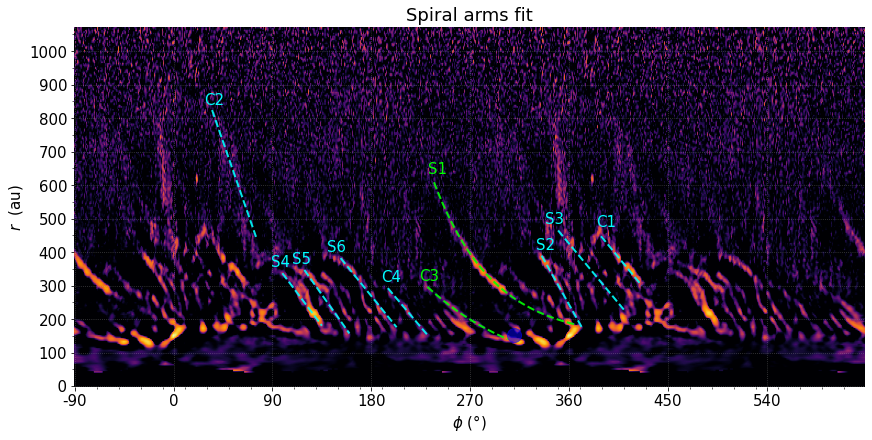

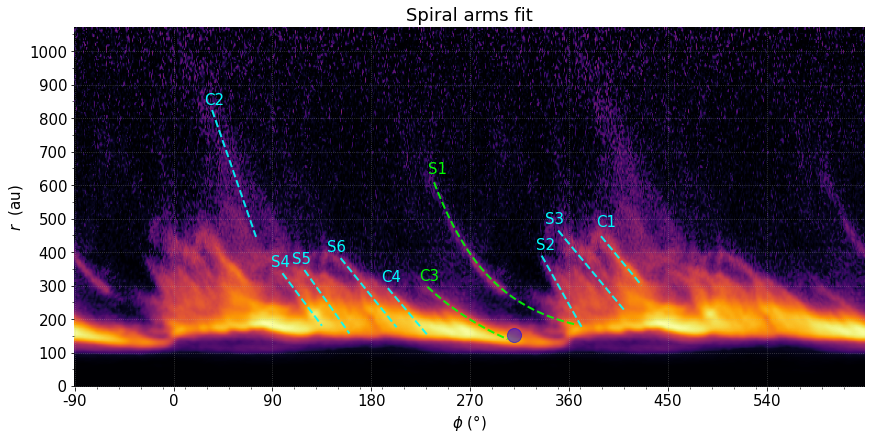

In [132]:
overplot_spirals( adi_ext, best_df, text=True, qphi=False, folder='./Datapoints/')
overplot_spirals( Qphi_ext, best_df, text=True, folder='./Datapoints/')

Let's also fit the outer ring as a spiral arm: first divided in two chunks and then as a whole (O01)

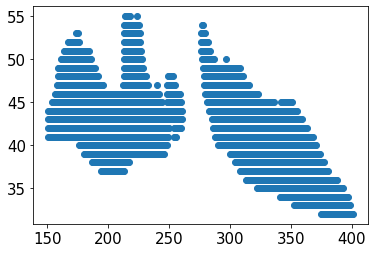

In [133]:
ys, xs = np.nonzero( Qphi_ext > 0.00045)        # for the outring itself
lim1 = (xs > 270) & (xs < 450)
lim2 = (xs > 150) & (xs < 245)
lim3 = (xs > 150) & (xs < 450)
plt.scatter( xs[lim3], ys[lim3])
plt.show()

arr1 = np.array( list( zip( xs[lim1],ys[lim1])) )
arr2 = np.array( list( zip( xs[lim2],ys[lim2])) )
arr3 = np.array( list( zip( xs[lim3],ys[lim3])) )

# np.savetxt( 'spi_O1.dat', arr1 )
# np.savetxt( 'spi_O2.dat', arr2 )
# np.savetxt( 'spi_O3.dat', arr3 )

In [134]:
mdf = perform_spiral_fit( folder='./Datapoints2/')
mdf.sort_values( by=['filename'], inplace=True )
mdf


,filename,spiral_type,a,b,phi0,r0,pitch_ang,chi2,std_a,std_b,std_phi0,std_r0,std_pitch
0,spi_C1_q,log,7.292445,-1.114015,183.724029,5.100000e+01,48.087139,2.697467,1.305398e+07,0.396956,9.206643e+07,31.398502,10.429814
8,spi_C1_q,arch,27.624890,-87.698102,130.584713,NaN,42.355268,3.084583,6.421541e+07,6.844874,4.195384e+07,NaN,2.228128
1,spi_C2_a,log,73.413577,-0.620679,225.146030,1.987470e-15,31.826991,0.060532,4.059098e+07,0.088702,5.103980e+07,7.690783,3.669598
9,spi_C2_a,arch,66.343159,-33.659076,234.002679,NaN,44.216461,0.041658,4.956912e+07,0.394477,8.437848e+07,NaN,0.335629
2,spi_C2_q,log,68.947682,-0.515968,228.354792,1.290057e-11,27.292268,0.025958,3.138338e+07,0.209171,5.054524e+07,23.897699,9.445728
10,spi_C2_q,arch,68.181463,-30.551607,228.877676,NaN,41.450489,0.023132,4.827537e+07,0.574670,9.053452e+07,NaN,0.534752
3,spi_O1,log,23.691602,-0.484143,178.940605,2.611981e+01,25.833604,0.232880,1.039857e+07,0.093624,5.194318e+07,2.743597,4.343160
11,spi_O1,arch,43.912141,-6.779752,213.203255,NaN,11.962208,0.234886,1.224472e+07,0.172793,1.034803e+08,NaN,0.296091
4,spi_O2,log,0.159218,-1.299451,166.751695,4.375161e+01,52.419708,0.368806,4.695562e+05,1.768930,1.300344e+08,0.935640,23.399945
12,spi_O2,arch,42.372653,-0.837483,250.569250,NaN,1.296650,0.368655,1.961840e+06,0.288396,1.342178e+08,NaN,0.446354


In [135]:
c1 = mdf.loc[[0]]           # best chi2
c2 = mdf.loc[[9,10]].mean( axis=0, numeric_only=True).to_frame().T      # Qphi-ADI mean
c2[['filename', 'spiral_type']] = ['C2', 'arch']
o1 = mdf.loc[[11]]
o2 = mdf.loc[[12]]
o3 = mdf.loc[[13]]
s1 = mdf.loc[[6,7]].mean( axis=0, numeric_only=True).to_frame().T      # Qphi-ADI mean
s1[['filename', 'spiral_type']] = ['S1', 'log']

best_df2 = pd.concat( [c1, c2, s1, o1, o2, o3], axis=0, ignore_index=True)
best_df2 = best_df2.rename( columns={'filename':'arm_name'})
best_df2.arm_name = best_df2.arm_name.str.replace( 'spi_', '').str.replace( '_q', '').str.replace( '_a', '')      # clean names
best_df2


,arm_name,spiral_type,a,b,phi0,r0,pitch_ang,chi2,std_a,std_b,std_phi0,std_r0,std_pitch
0,C1,log,7.292445,-1.114015,183.724029,51.000000,48.087139,2.697467,1.305398e+07,0.396956,9.206643e+07,31.398502,10.429814
1,C2,arch,67.262311,-32.105341,231.440178,NaN,42.833475,0.032395,4.892225e+07,0.484574,8.745650e+07,NaN,0.435190
2,S1,log,106.754157,-1.037325,238.042037,30.979237,45.981951,0.046614,3.091085e+07,0.031367,1.603374e+07,1.773743,0.876601
3,O1,arch,43.912141,-6.779752,213.203255,NaN,11.962208,0.234886,1.224472e+07,0.172793,1.034803e+08,NaN,0.296091
4,O2,arch,42.372653,-0.837483,250.569250,NaN,1.296650,0.368655,1.961840e+06,0.288396,1.342178e+08,NaN,0.446354
5,O3,arch,33.969449,-2.146311,404.075898,NaN,3.837208,0.379199,6.108472e+06,0.068333,1.630657e+08,NaN,0.121802


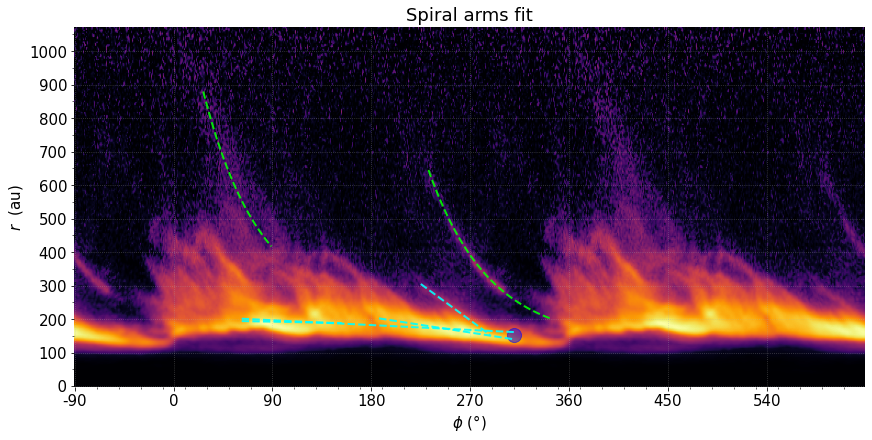

In [136]:
overplot_spirals( Qphi_ext, best_df2, text=False, folder='./Datapoints2/')
# best_df2.to_csv( 'Spiral_best-fit_results2.txt', sep='\t', na_rep='NaN')

### Running OUTRING fit

Now let's try to fit the OUTRING piece by piece and produce a pitch angle diagram

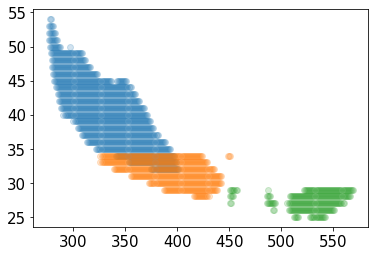

(1921, 2)

In [137]:
ys1, xs1 = np.nonzero( Qphi_ext > 0.00045)        # for the outring itself
lim1 = (xs1 > 270) & (xs1 < 450)
ys2, xs2 = np.nonzero( Qphi_ext > 0.00018) 
lim2 = (xs2 > 325) & (xs2 < 570) & ( ys2 < 35)
ys3, xs3 = np.nonzero( Qphi_ext > 4.1e-05) 
lim3 = (xs3 > 450) & (xs3 < 570) & ( ys3 < 30)

plt.scatter( xs1[lim1], ys1[lim1], alpha = 0.2)
plt.scatter( xs2[lim2], ys2[lim2], alpha = 0.2)
plt.scatter( xs3[lim3], ys3[lim3], alpha = 0.2)
plt.show()

xs = np.concatenate( [xs1[lim1], xs2[lim2], xs3[lim3]])
ys = np.concatenate( [ys1[lim1], ys2[lim2], ys3[lim3]])

arr = np.array( list( zip( xs, ys)) )
# np.savetxt( 'spi_Rs.dat', arr )
arr.shape

In [7]:
def overplot_running_spirals( img, spiral_df, windowsize, pixscale=ird_scale):
    '''
    Create a plot of the spiral arm running fit over the extended image img. Only for arch spirals now.
    '''
    ptitle = 'Spiral arm running fit'
    fig, ax = plt.subplots( figsize=(12,6), constrained_layout=True)
    cnorm = mpl.colors.SymLogNorm( linthresh=1, linscale=0.1, base=10)     # vmin=img.min(), vmax=img.max(), linthresh 2.e-05 
    ax.imshow( img, origin='lower', cmap='inferno', norm=cnorm, aspect='auto')
    au_deg_ticks( ax, -90, pixscale=pixscale)        # this only changes the label format, not the actual xy values of rows n cols
    ax.grid(True, alpha=0.4, linestyle=':')
    ax.set( title= ptitle, xlabel= '$\phi $ (°)', ylabel= '$r$  (au)', frame_on =False)
    ax.scatter( -50 + 360 - polshift, 35.5, marker='o', s=200, c='blue', alpha=0.5)     # centre of the dust TRAP
    fig.canvas.manager.set_window_title( ptitle)
    for i in range( spiral_df.shape[0]):
        x, y = plot_spiral( img, spiral_df.spiral_type[i], spiral_df.a[i], spiral_df.b[i], phi0=spiral_df.phi0[i], polshift=-90)
        margin = windowsize/2     # pix
        #xlims, ylims = arm_bounds( spiral_df.arm_name[i], folder=folder )
        #ybounds = ( y > ylims[0] - margin ) & ( y < ylims[1] + margin )
        xbounds = ( x > spiral_df.i[i] - margin ) & ( x < spiral_df.i[i] + margin )
        ax.plot( x[ xbounds], y[ xbounds], lw=2, c='cyan', ls='-' , alpha=0.2)
    plt.show()



def running_fit( datapoints, windsize=100, windstep=5, figures=True):
    '''
    Perform a spiral fit of a window of windsize pixels, running over the datapoints at steps of windstep.
    '''
    spiral_func = arch_spiral
    sp_type = 'arch'
    arch_array = np.array([])
    param_bounds = ( [-250, -np.inf, -360], [250, np.inf, 720] )           # limits on spiral parameters a, b, phi0

    for i in range( int(datapoints[:,0].min() + windsize/2), int(datapoints[:,0].max() - windsize/2), windstep ):   # running window on the angles axis
        points = datapoints[ (i - windsize/2 <= datapoints[:,0]) & (datapoints[:,0] < i + windsize/2) ]             # windows centred on pixel i
        phi_0, r_0 = np.median( points[:], axis=0)
        init_guess = ([r_0, -0.5, phi_0])        # a, b, phi0 guesses
        IN_popt, IN_pcov = curve_fit( spiral_func, xdata= points[:,0], ydata= points[:,1], p0=init_guess, bounds=param_bounds, absolute_sigma=False )
        fit_stds = np.sqrt(np.diag( IN_pcov ))          # from scipy doc
        y_pred = spiral_func( points[:,0], *IN_popt)       # fit predictions
        res = y_pred - points[:,1]                        # residues
        chisq = sum( res**2 / y_pred) / ( len(points) - len(init_guess) )        # reduced chi-square
        pitch_ang = pitch_angle( sp_type=sp_type, b= IN_popt[1], absval=True, r_ev= r_0 )
        pitch_std = pitch_error( sp_type=sp_type, b_best=IN_popt[1], stds=fit_stds, r_ev= r_0 )
        arch_array = np.concatenate( (arch_array, [i, 'arch', *IN_popt, pitch_ang, chisq, *fit_stds, pitch_std]) )
            
    column_arch = { 0:'i', 1:'spiral_type', 2:'a', 3:'b', 4:'phi0', 5:'pitch_ang', 6:'chi2', 7:'std_a', 8:'std_b', 9:'std_phi0', 10:'std_pitch'}
    arch_df = pd.DataFrame( arch_array.reshape( -1, 11 )  )
    arch_df.rename( columns= column_arch, inplace=True )
    for df in [arch_df]:
        for i in range(2, df.shape[1]):
            df.iloc[:, i] = df.iloc[:, i].astype(float)     # pandas won't change dtype for many columns at once bah
        df.i = df.i.astype(float)

    if figures:
        overplot_running_spirals( img=Qphi_ext, spiral_df=arch_df, windowsize=windsize)
        fig, ax = plt.subplots()
        ax.plot( arch_df.i -90, arch_df.pitch_ang)
        ax.set( xlabel='$\phi$ (°)', ylabel='pitch angle  (°)', xscale='linear', yscale='linear')
        plt.show()
    return arch_df

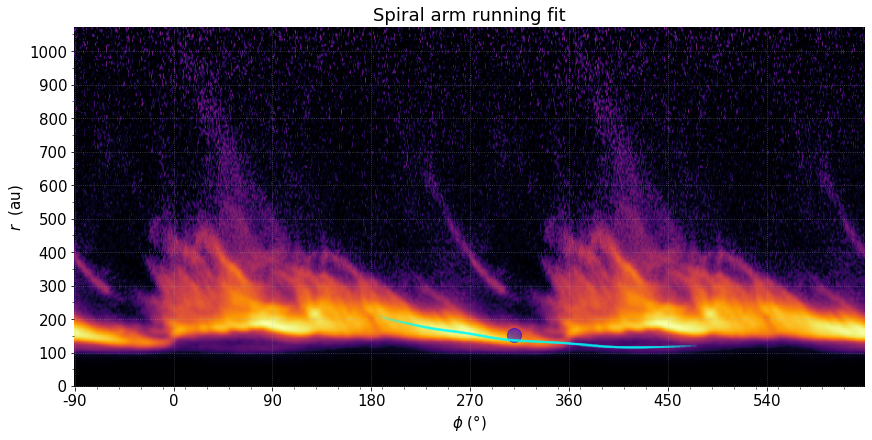

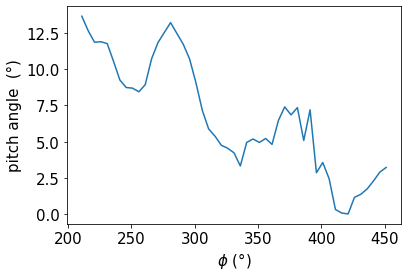

In [146]:
adf = running_fit( arr, windsize=50, windstep=5, figures=True)
#plt.plot( adf.pitch_ang)

In [150]:
# adf

## Last simple Fit



#### OUTring fit con unica spirale 

fit: a= 40.597 [pix], b= -3.230 [1/rad], phi0= 248.84 [deg]
Fit 1 sigma errors: [6.54158478e+06 7.02686491e-02 1.16037920e+08]
reduced chi-square of fit: 	 0.903
abs pitch angle: [deg] 	 7.36


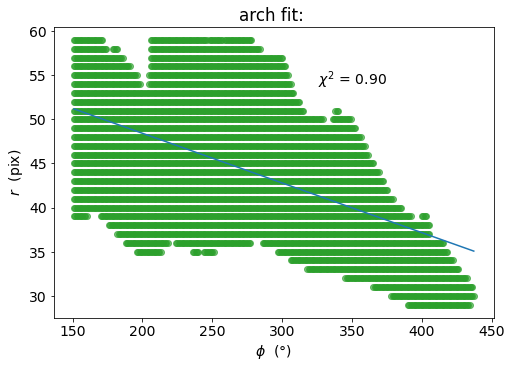

In [10]:
rs, phis = np.nonzero( Qphi_ext > 13)        # for the outring itself
lim1 = (phis > 150) & (phis < 440) & (rs < 60)
# plt.scatter( phis[lim1], rs[lim1], alpha = 0.2)
# plt.show()

outring_coords = np.array( list( zip( phis[lim1], rs[lim1])) )
np.savetxt( './Datapoints3/outring_q.dat', outring_coords)

# # ALTERNATIVA :prendo i punti medi dell'outring per non fare troppa confusione
# r2_pos = raf.r2_factors( Qphi_ext, mask_under=15, data_smooth=2, r2_smooth=2, figure=True)     # find the radial coordinates
# phi_lims = [150, 440]      # take the central outring in the extended image
# r_arr = np.sqrt( r2_pos[ phi_lims[0] : phi_lims[1] ] )#.astype('int')
# phi_arr = np.arange( *phi_lims )

# outring_coords = np.array( list( zip( phi_arr, r_arr)) )
# np.savetxt( './Datapoints2/outring_coords_r2.dat', outring_coords)


ringdata = np.loadtxt( './Datapoints3/outring_q.dat')
_ = fit_spiral( ringdata, 'arch')

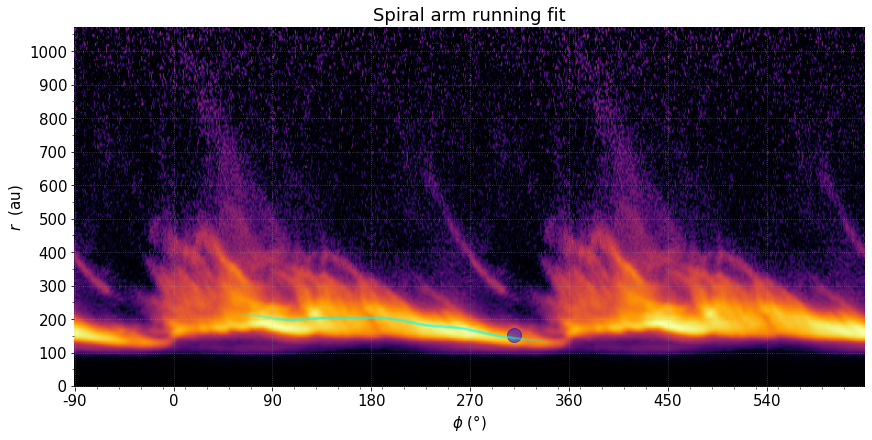

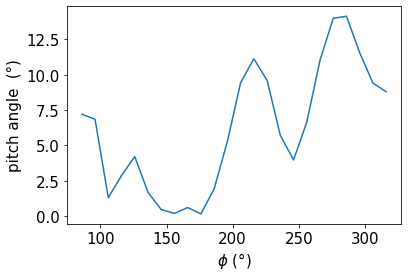

In [125]:
## A bit more fancy, with the pitch angle varying with phi
df7 = running_fit( ringdata, 50, 10)

#### 3 arms fit final

In [9]:
fdf = perform_spiral_fit( './Datapoints4/')
# print( fdf)

o1 = fdf.loc[[3]]   # arch
s1 = fdf.loc[[2]]   # log
c1 = fdf.loc[[1]]   # log

best_df3 = pd.concat( [ s1, c1, o1], axis=0, ignore_index=True)
best_df3 = best_df3.rename( columns={'filename':'arm_name'})
best_df3.arm_name = best_df3.arm_name.str.replace( 'spi_', '').str.replace( '_q', '').str.replace( '_a', '')      # clean names
best_df3

NameError: name 'perform_spiral_fit' is not defined

In [8]:
Qphi_ext_sm = create_ext_img( Qphi_fname, smoothing=1.6) [:, :540]
overplot_spirals( Qphi_ext_sm, best_df3, text=True, folder='./Datapoints4/')

Fits HDU-0 data successfully loaded. Data shape: (1024, 1024)
Filename: /home/gabriele/ExoDisks/HD34700_27-10-2019_r/HD34700_IRD-2019_Qphi_clean.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      70   (1024, 1024)   float32   
New shape: (1023, 1023)


NameError: name 'best_df3' is not defined

### ZIMPOL outring fit

Fits HDU-0 data successfully loaded. Data shape: (1023, 1023)
Filename: /home/gabriele/ExoDisks/gab_products/HD_34700_A/ZIMP_INmasked_TN.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (1023, 1023)   float32   
New shape: (1023, 1023)


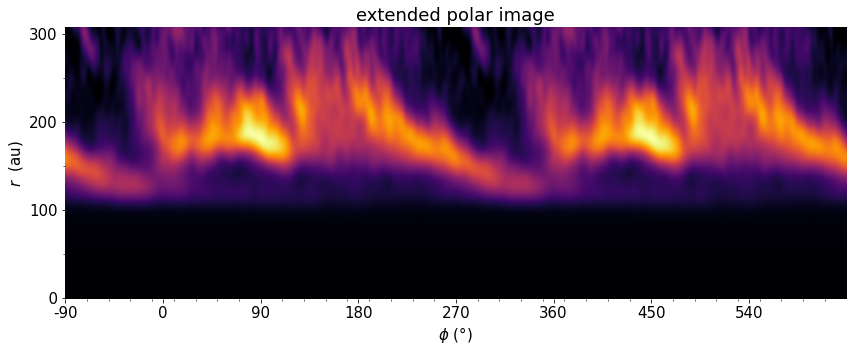

In [36]:
zQphi_fname = '/home/gabriele/ExoDisks/gab_products/HD_34700_A/ZIMP_INmasked_TN.fits'     # ZIMPOL masked Qphi
# Qphi_fname = '/home/gabriele/ExoDisks/ZIMPOL_HD34700A__reduced/Qphi12_Ha.fits'        # non-masked ZIMP 

zQphi_ext = create_ext_img( zQphi_fname, smoothing=8, pixscale=zimp_scale, figure=True)

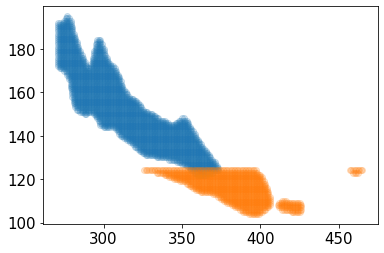

In [149]:
ys1, xs1 = np.nonzero( zQphi_ext > 0.7)        # for the outring itself
lim1 = (xs1 > 270) & (xs1 < 450)
ys2, xs2 = np.nonzero( zQphi_ext > 0.5) 
lim2 = (xs2 > 325) & (xs2 < 500) & ( ys2 < 125)
# ys3, xs3 = np.nonzero( Qphi_ext > 0.45) 
# lim3 = (xs3 > 350) & (xs3 < 570) & ( ys3 < 120)

plt.scatter( xs1[lim1], ys1[lim1], alpha = 0.2)
plt.scatter( xs2[lim2], ys2[lim2], alpha = 0.2)
# plt.scatter( xs3[lim3], ys3[lim3], alpha = 0.2)
plt.show()

# xs = np.concatenate( [xs1[lim1], xs2[lim2], xs3[lim3]])
# ys = np.concatenate( [ys1[lim1], ys2[lim2], ys3[lim3]])
# arr = np.array( list( zip( xs, ys)) )
# np.savetxt( 'spi_Rs.dat', arr )
